In [ ]:
from flower_model._kmeans import _spherical_kmeans
from flower_model.external._gabor_like_filters import _gabor_like_filters
from flower_model._filterbank import _shift_filters
import torch
import matplotlib.pyplot as plt
import math
import numpy as np

In [ ]:
N = 31
sigma = 15.
k = 250
steps = 16
SPH_KMEANS_ITERS = 50
device='cuda'

low_freq_upper= 3.7
high_freq_lower = 10.6

eye_pos = [15.5, 15.5]
k_around_eye = 12

In [51]:
filters, r = _gabor_like_filters(N, sigma, 20, 1)
print(filters.shape)
print(r.shape)

/cluster/home/vetletb/projects/Bacheloroppgave-gr82-feature-extraction/src/gabor_like/external/_gaussian.py:21: RuntimeWarning: invalid value encountered in divide
  (n + np.array([l1, l2]).reshape(-1, 1, 1))


(1281, 31, 31)
(1281,)


In [52]:
filters = filters.astype("complex64")
filters = torch.tensor(filters, device=device)
filters = torch.abs(filters)

r = torch.tensor(r, device=device)

In [53]:
filters, filter_pos = _shift_filters(filters, steps, N+1)
shift_dim = filters.size(dim=1)

r = r.repeat((steps*2)**2)

print(filters.shape)
print(filter_pos.shape)
print(r.shape)

torch.Size([1311744, 62, 62])
torch.Size([1311744, 2])
torch.Size([1311744])


In [54]:
filter_amount = filters.size(dim=0)
filters = filters.view(filter_amount, -1)

In [55]:
labels = _spherical_kmeans(k, filters, SPH_KMEANS_ITERS)

In [56]:
centroid_list = []
centroid_r_list = []
centroid_pos_list = []

for cluster in range(k):
    cluster_mask = labels == cluster
    filters_in_cluster = filters[cluster_mask]
    r_in_cluster = r[cluster_mask]
    pos_in_cluster = filter_pos[cluster_mask]

    centroid_list.append(torch.mean(filters_in_cluster, dim=0))
    centroid_r_list.append(torch.mean(r_in_cluster))
    centroid_pos_list.append(torch.mean(pos_in_cluster, dim=0))

centroids = torch.stack(centroid_list)
centroids_r = torch.hstack(centroid_r_list)
centroids_pos = torch.stack(centroid_pos_list)

print(centroids.shape)
print(centroids_r.shape)
print(centroids_pos.shape)

centroids = centroids.view(-1, shift_dim*shift_dim)

torch.Size([250, 3844])
torch.Size([250])
torch.Size([250, 2])


tensor([25.3421, 27.3135], device='cuda:0')


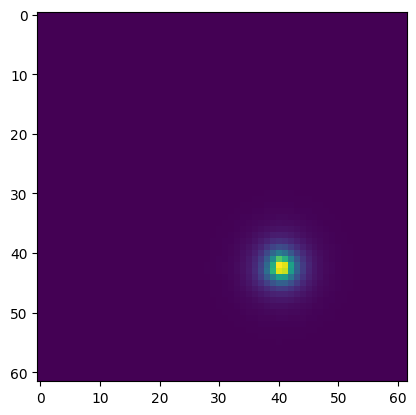

In [57]:
print(centroids_pos[0])
plt.imshow(centroids[0].view(shift_dim, shift_dim).cpu())
plt.show()

In [58]:
low_freq_upper= 10.
high_freq_lower = 10.

low_freq_mask = centroids_r < low_freq_upper
high_freq_mask = centroids_r > high_freq_lower

low_freq_centroids = centroids[low_freq_mask]
high_freq_centroids = centroids[high_freq_mask]

print(low_freq_centroids.shape)
print(high_freq_centroids.shape)

torch.Size([67, 3844])
torch.Size([183, 3844])


In [59]:
eye_pos = torch.tensor(eye_pos, device=device)
pos_diff = centroids_pos - eye_pos
centoroid_distance = torch.linalg.vector_norm(pos_diff, dim=1)

low_freq_distance = centoroid_distance[low_freq_mask]
high_freq_distance = centoroid_distance[high_freq_mask]

low_freq_centroids_eye = low_freq_centroids[low_freq_distance.topk(k_around_eye, largest=False).indices]
high_freq_centroids_eye = high_freq_centroids[high_freq_distance.topk(k_around_eye, largest=False).indices]

print(low_freq_centroids_eye.shape)
print(high_freq_centroids_eye.shape)

torch.Size([10, 3844])
torch.Size([10, 3844])


In [60]:
print(low_freq_distance.topk(k_around_eye, largest=False).values)
print(high_freq_distance.topk(k_around_eye, largest=False).values)

tensor([0.9400, 2.8628, 4.4970, 4.9916, 5.1485, 5.4810, 5.6240, 6.0865, 6.1065,
        7.0399], device='cuda:0')
tensor([0.5905, 1.9083, 2.5272, 2.6882, 2.7602, 2.9051, 3.1962, 3.5267, 4.1213,
        4.1237], device='cuda:0')


torch.Size([10, 3844])


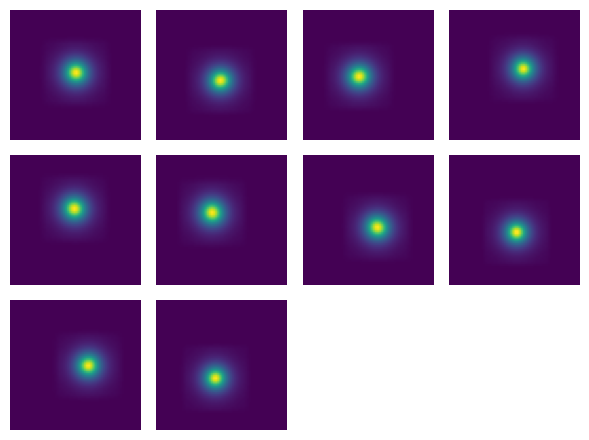

torch.Size([10, 3844])


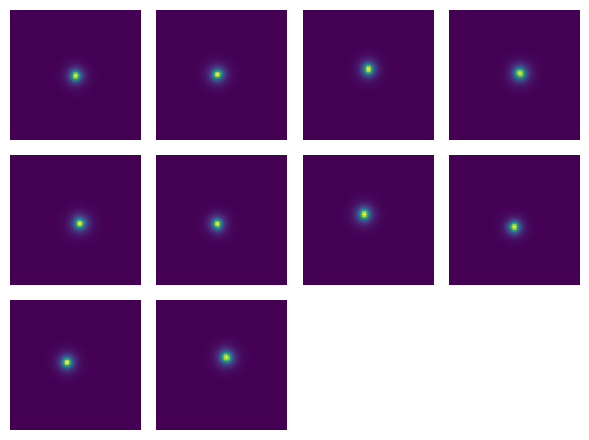

In [61]:
for c in [low_freq_centroids_eye, high_freq_centroids_eye]:
    f = c.squeeze(0).cpu()
    print(f.shape)
    n = f.shape[0]
    size = int(math.sqrt(f.shape[1]))
    assert size * size == f.shape[1], "expected square (H*W)"

    cols = int(math.ceil(math.sqrt(n)))
    rows = int(math.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols*1.5, rows*1.5))
    axes = np.atleast_1d(axes).flatten()

    for i in range(rows * cols):
        ax = axes[i]
        if i < n:
            img = f[i].reshape(size, size).numpy()
            ax.imshow(img, cmap="viridis")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

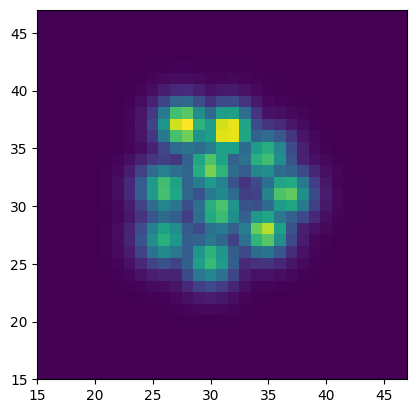

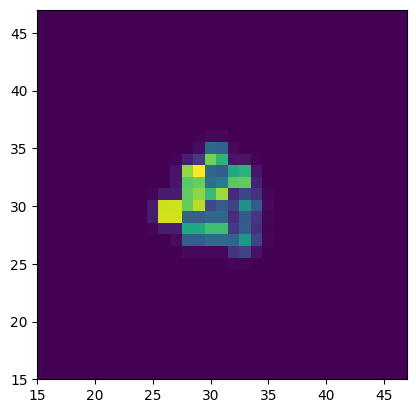

In [62]:
scale = 5
for c in [low_freq_centroids_eye**scale, high_freq_centroids_eye**scale]:
    f = c.amax(dim=0)
    f = f.view(shift_dim, shift_dim)
    plt.imshow(f.cpu())
    plt.xlim(shift_dim//2 - (N+1)//2, shift_dim//2 - (N+1)//2 + N+1)
    plt.ylim(shift_dim//2 - (N+1)//2, shift_dim//2 - (N+1)//2 + N+1)
    plt.show()

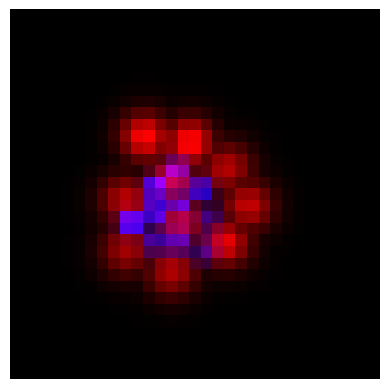

In [63]:
img1 = low_freq_centroids_eye.amax(dim=0).view(shift_dim, shift_dim)**scale
img3 = high_freq_centroids_eye.amax(dim=0).view(shift_dim, shift_dim)**scale

max = torch.stack([img1, img3]).max()
min = torch.stack([img1, img3]).min()

def normalize(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

img1 = normalize(img1)
img3 = normalize(img3)

rgb = torch.stack([img1, torch.zeros(shift_dim, shift_dim, device=device), img3], dim=-1)

rgb_np = rgb.cpu().numpy()

plt.imshow(rgb_np)
plt.axis("off")
plt.xlim((shift_dim-N+1)//2, (shift_dim-N+1)//2 + N+1)
plt.ylim((shift_dim-N+1)//2, (shift_dim-N+1)//2 + N+1)
plt.show()

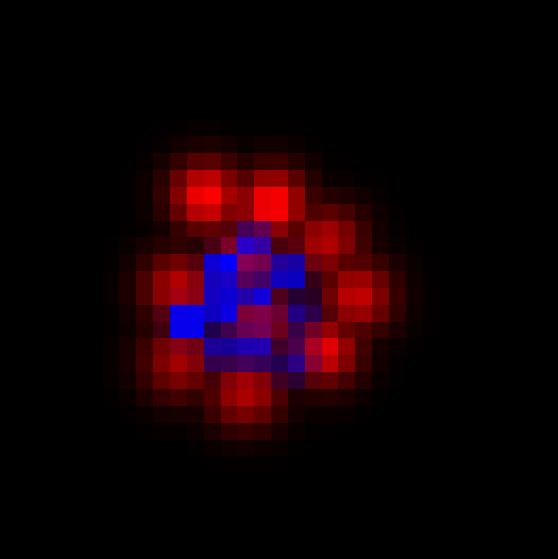

In [64]:
img_low  = (low_freq_centroids_eye**1).amax(dim=0).view(shift_dim, shift_dim)**scale
img_high = (high_freq_centroids_eye**1).amax(dim=0).view(shift_dim, shift_dim)**scale

max = torch.stack([img_low,  img_high]).max()
min = torch.stack([img_low, img_high]).min()

low  = normalize(img_low).cpu().numpy()
high = normalize(img_high).cpu().numpy()

H, W = low.shape

layer_low = torch.zeros(H, W, 4)
layer_high = torch.zeros(H, W, 4)

layer_low[..., 0] = 1.0
layer_low[..., 3] = torch.tensor(low)

layer_high[..., 2] = 1.0
layer_high[..., 3] = torch.tensor(high)

layer_low  = layer_low.numpy()
layer_high = layer_high.numpy()

fig, ax = plt.subplots(figsize=(7, 7), facecolor="black")
ax.set_facecolor("black")

ax.imshow(layer_low)
ax.imshow(layer_high)

ax.axis("off")
ax.set_xlim((shift_dim-N+1)//2, (shift_dim-N+1)//2 + N+1)
ax.set_ylim((shift_dim-N+1)//2, (shift_dim-N+1)//2 + N+1)
plt.show()

In [65]:
low_freq_pos = centroids_pos[low_freq_mask]
high_freq_pos = centroids_pos[high_freq_mask]

low_freq_pos_eye = low_freq_pos[low_freq_distance.topk(k_around_eye, largest=False).indices]
high_freq_pos_eye = high_freq_pos[high_freq_distance.topk(k_around_eye, largest=False).indices]

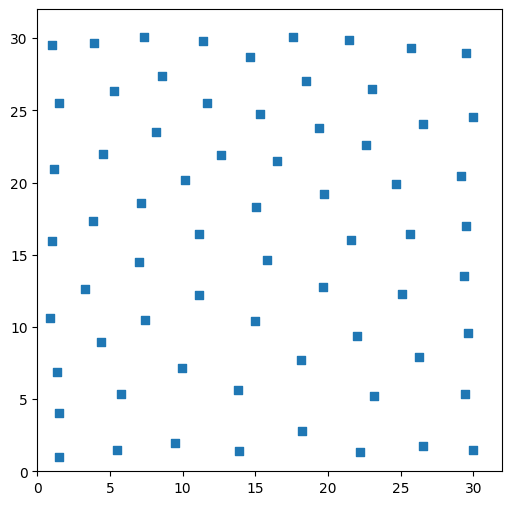

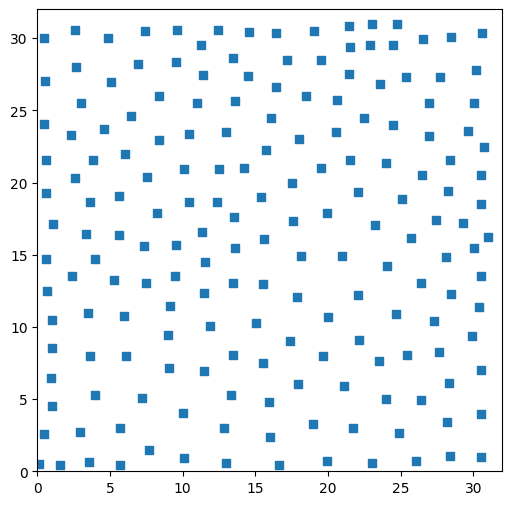

In [66]:
low = low_freq_pos.cpu().numpy()
high = high_freq_pos.cpu().numpy()

for f in [low, high]:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(f[:, 0], f[:, 1], marker="s")
    ax.set_xlim(0, N+1)
    ax.set_ylim(0, N+1)
    plt.show()

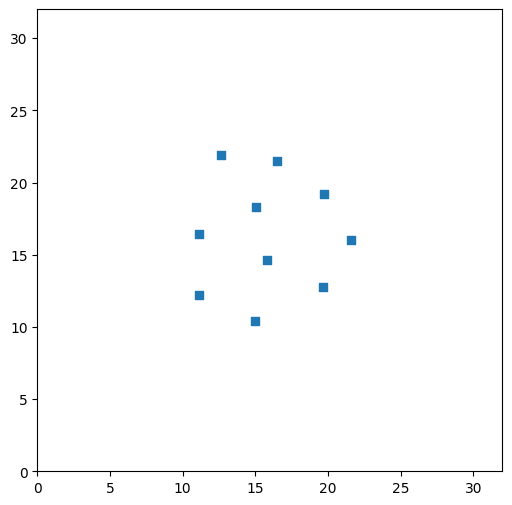

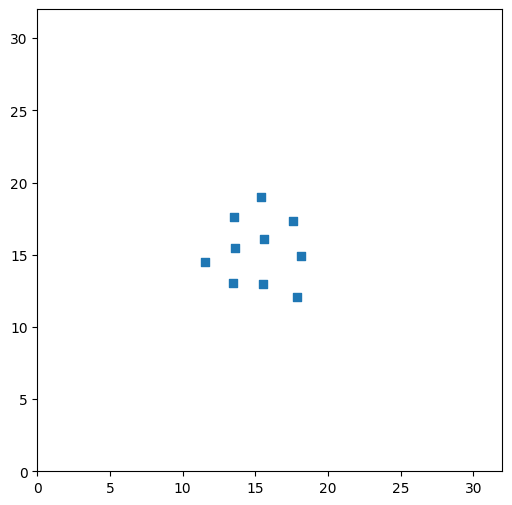

In [67]:
low = low_freq_pos_eye.cpu().numpy()
high = high_freq_pos_eye.cpu().numpy()

for f in [low, high]:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(f[:, 0], f[:, 1], marker="s")
    ax.set_xlim(0, N+1)
    ax.set_ylim(0, N+1)
    plt.show()

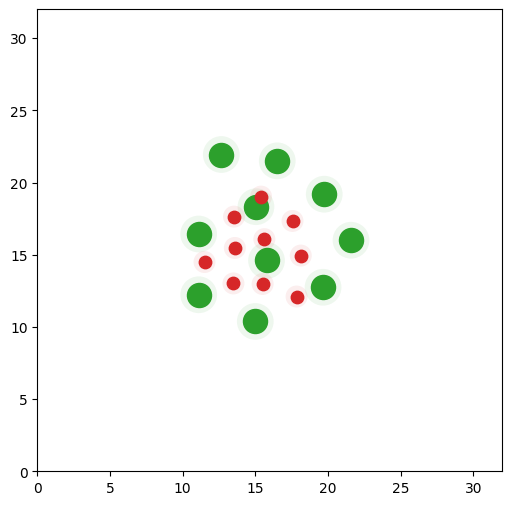

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(low[:,0], low[:,1], s=700, c="tab:green", marker="o", alpha=0.08, edgecolors="none")
ax.scatter(high[:,0], high[:,1], s=250, c="tab:red", marker="o", alpha=0.08, edgecolors="none")

ax.scatter(low[:,0], low[:,1], s=300, c="tab:green", marker="o")
ax.scatter(high[:,0], high[:,1], s=80, c="tab:red", marker="o")

ax.set_xlim(0, N+1)
ax.set_ylim(0, N+1)
plt.show()